In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

path = Path("/content/drive/MyDrive/Jewelry_Project/powerbi_data.parquet")


df = pd.read_parquet(path)
df.head(5)

,parent_asin,brand,average_rating,rating_number,price,rating,Jewelry_type,Jewelry_subtype,year,month
0,B000AOVARS,Silver Insanity,1.5,2.0,54.00,2.0,Bracelets,Link,2005,10
1,B000BD25OU,Sabrina Silver,2.0,1.0,124.96,2.0,Bracelets,Cuff,2005,10
2,B0002XP1OK,Silver Insanity,4.4,11.0,59.97,5.0,Bracelets,Cuff,2005,4
3,B0001CUKSY,SE,3.9,86.0,11.99,3.0,Watch Accessories,Repair Tools & Kits,2005,11
4,B00011V8YU,NOVICA,4.1,129.0,67.49,4.0,Jewelry,Anklets,2005,5


In [2]:
df.columns

Index(['parent_asin', 'brand', 'average_rating', 'rating_number', 'price',
       'rating', 'Jewelry_type', 'Jewelry_subtype', 'year', 'month'],
      dtype='object')

In [3]:
df.dtypes

,0
parent_asin,object
brand,object
average_rating,float64
rating_number,float64
price,float64
rating,float64
Jewelry_type,object
Jewelry_subtype,object
year,int32
month,int32


In [4]:
df.shape

(1146700, 10)

In [5]:
df.describe()

,average_rating,rating_number,price,rating,year,month
count,1.146700e+06,1.146700e+06,1.146700e+06,1.146700e+06,1.146700e+06,1.146700e+06
mean,4.403884e+00,3.180278e+03,2.985815e+01,4.232113e+00,2.019651e+03,6.247890e+00
std,3.319260e-01,6.235940e+03,7.659443e+01,1.326828e+00,2.433180e+00,3.633713e+00
min,1.000000e+00,1.000000e+00,1.000000e-02,1.000000e+00,2.005000e+03,1.000000e+00
25%,4.300000e+00,2.210000e+02,1.199000e+01,4.000000e+00,2.018000e+03,3.000000e+00
50%,4.500000e+00,9.320000e+02,1.645000e+01,5.000000e+00,2.020000e+03,6.000000e+00
75%,4.600000e+00,3.111000e+03,2.698000e+01,5.000000e+00,2.022000e+03,9.000000e+00
max,5.000000e+00,4.977900e+04,9.999990e+03,5.000000e+00,2.023000e+03,1.200000e+01


In [6]:
df.isna().sum()

,0
parent_asin,0
brand,0
average_rating,0
rating_number,0
price,0
rating,0
Jewelry_type,0
Jewelry_subtype,0
year,0
month,0


In [7]:
df.loc[df.duplicated()]

,parent_asin,brand,average_rating,rating_number,price,rating,Jewelry_type,Jewelry_subtype,year,month
81,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2007,11
95,B00094F6K6,Silver Insanity,3.6,23.0,12.00,5.0,Bracelets,Bangle,2007,5
96,B0007QR92O,Silver Insanity,3.4,29.0,6.00,5.0,Bracelets,Cuff,2007,5
97,B000EREX34,Paylak,4.2,141.0,12.98,4.0,Watch Accessories,Repair Tools & Kits,2007,5
115,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2007,11
...,...,...,...,...,...,...,...,...,...,...
1146683,B09SHV4BPQ,Emibele,4.5,157.0,13.99,5.0,Jewelry Boxes & Organizers,Jewelry Trays,2023,2
1146684,B08YRC64P4,LVSOMT,4.6,693.0,139.99,5.0,Jewelry Boxes & Organizers,Jewelry Armoires,2023,3
1146689,B08YRC64P4,LVSOMT,4.6,693.0,139.99,5.0,Jewelry Boxes & Organizers,Jewelry Armoires,2023,3
1146697,B0BLYMPP45,Party-rainday,4.8,76.0,13.99,5.0,Jewelry Boxes & Organizers,Jewelry Boxes,2023,3


In [15]:
# df.loc[df.duplicated(subset='parent_asin')]

In [8]:
df.query('parent_asin == "B000A3BVSM"')

,parent_asin,brand,average_rating,rating_number,price,rating,Jewelry_type,Jewelry_subtype,year,month
25,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2006,12
29,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2006,11
32,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2006,9
54,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2007,7
65,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2007,11
...,...,...,...,...,...,...,...,...,...,...
193601,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2017,9
234550,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2018,1
269971,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,2.0,Jewelry,Anklets,2018,4
680084,B000A3BVSM,Gem Avenue,4.1,112.0,26.99,5.0,Jewelry,Anklets,2021,7


In [9]:
df["parent_asin"].value_counts()

,count
parent_asin,
B0BXWWKJZC,5171
B0B5XRKN3X,5031
B0BZR14VNF,3943
B08NYR5CWH,3791
B07NPJ4K12,3685
...,...
B0B49MVMZX,1
B0BYSNKM9J,1
B0BHF66SMP,1


In [10]:
df['Jewelry_type'].value_counts()

,count
Jewelry_type,
Bracelets,413107
Jewelry Boxes & Organizers,278115
Shoe Care & Accessories,133347
Jewelry,131442
Watch Accessories,48128
Jewelry Accessories,43861
Shoe Care Treatments & Dyes,30232
Charm Bracelets,26552
"Shoe, Jewelry & Watch Accessories",19867


In [19]:
#data needs further cleaning as Girls, boys , etc are not jewelry types
#also some of the jewelry types has to be merged to one
not_jewelry_types = ['Girls', 'Boys', 'Women', 'Men','Clothing, Shoes & Jewelry']
df = df[~df['Jewelry_type'].isin(not_jewelry_types)].reset_index(drop=True).copy()

type_mapping = {
    "Charms & Charm Bracelets": "Charm Bracelets",
    "Necklaces & Pendants": "Necklaces",
    "Pendants & Coins": "Necklaces",
    "Piercing Jewelry": "Body Jewelry",
    "Shoe, Jewelry & Watch Accessories": "Watch Accessories",
    "Shoe Care Treatments & Dyes": "Shoe Care & Accessories",
}
df["Jewelry_type"] = df["Jewelry_type"].replace(type_mapping).reset_index(drop=True).copy()

df['Jewelry_type'].value_counts()


,count
Jewelry_type,
Bracelets,413107
Jewelry Boxes & Organizers,278115
Shoe Care & Accessories,163579
Jewelry,131442
Watch Accessories,67995
Jewelry Accessories,43861
Charm Bracelets,31442
Necklaces,6726
Earrings,2821


In [20]:
df.shape

(1142668, 10)

In [13]:
pd.set_option('display.max_rows', None)
df['Jewelry_subtype'].value_counts()

,count
Jewelry_subtype,
Jewelry Boxes,126222
Link,100854
Cuff,75209
Anklets,66661
Jewelry Towers,65118
Bangle,62580
Stretch,61686
Bracelets,51786
Shoe & Boot Trees,51144


In [21]:
df.to_parquet("/content/drive/MyDrive/Jewelry_Project/cleaned_powerBI_data.parquet", index=False)

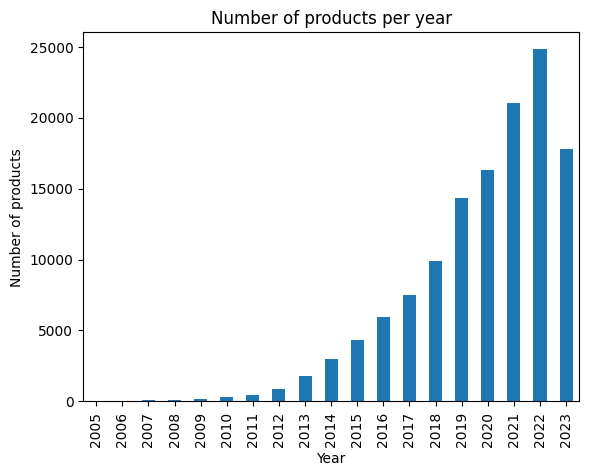

In [14]:
#Each year how many products (parent asin) are there
#each parent asin is counted only one time - no duplicates
# df.groupby('year')['parent_asin'].nunique()
ax = df.drop_duplicates(subset=['year', 'parent_asin'])['year'].value_counts().sort_index() \
.plot(kind='bar', title= 'Number of products per year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of products')

plt.show()


0.01 9999.99


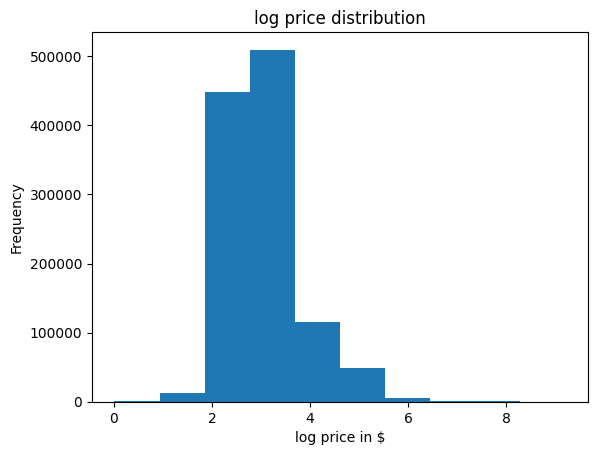

In [15]:
#how is the price distribution
print(df['price'].min(), df['price'].max())
ax = np.log1p(df['price']).plot(kind='hist', bins = 10, title='log price distribution')
ax.set_xlabel('log price in $')
plt.show()


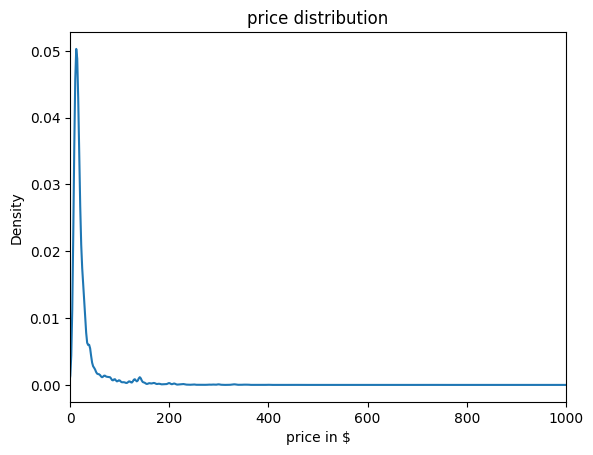

In [17]:
ax = df[df['price']<1000]['price'].plot(kind='kde', title='price distribution')
ax.set_xlabel('price in $')
ax.set_xlim(0,1000)
plt.show()

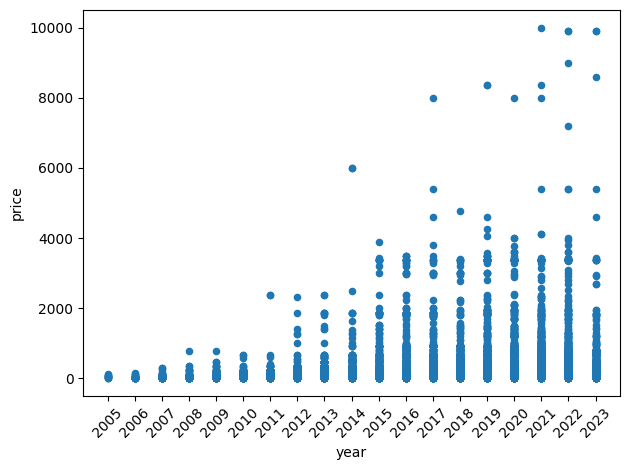

In [30]:
ax = df.plot(kind='scatter', x='year', y='price')
years = list(range(2005, 2024))
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
plt.tight_layout()
plt.show()

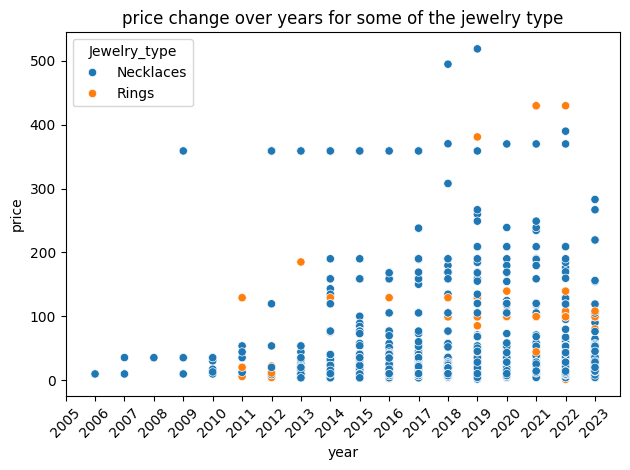

In [34]:
#having some of the jewelry types as hue
jewelry_types_filter = ['Rings', 'Necklaces']
df_filtered = df[df['Jewelry_type'].isin(jewelry_types_filter)]
ax = sns.scatterplot(x='year',y='price',hue='Jewelry_type',data=df_filtered)
ax.set_title('price change over years for some of the jewelry type')
years = list(range(2005, 2024))
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
plt.tight_layout()
plt.show()

In [36]:
df.head(5)

,parent_asin,brand,average_rating,rating_number,price,rating,Jewelry_type,Jewelry_subtype,year,month
0,B000AOVARS,Silver Insanity,1.5,2.0,54.00,2.0,Bracelets,Link,2005,10
1,B000BD25OU,Sabrina Silver,2.0,1.0,124.96,2.0,Bracelets,Cuff,2005,10
2,B0002XP1OK,Silver Insanity,4.4,11.0,59.97,5.0,Bracelets,Cuff,2005,4
3,B0001CUKSY,SE,3.9,86.0,11.99,3.0,Watch Accessories,Repair Tools & Kits,2005,11
4,B00011V8YU,NOVICA,4.1,129.0,67.49,4.0,Jewelry,Anklets,2005,5


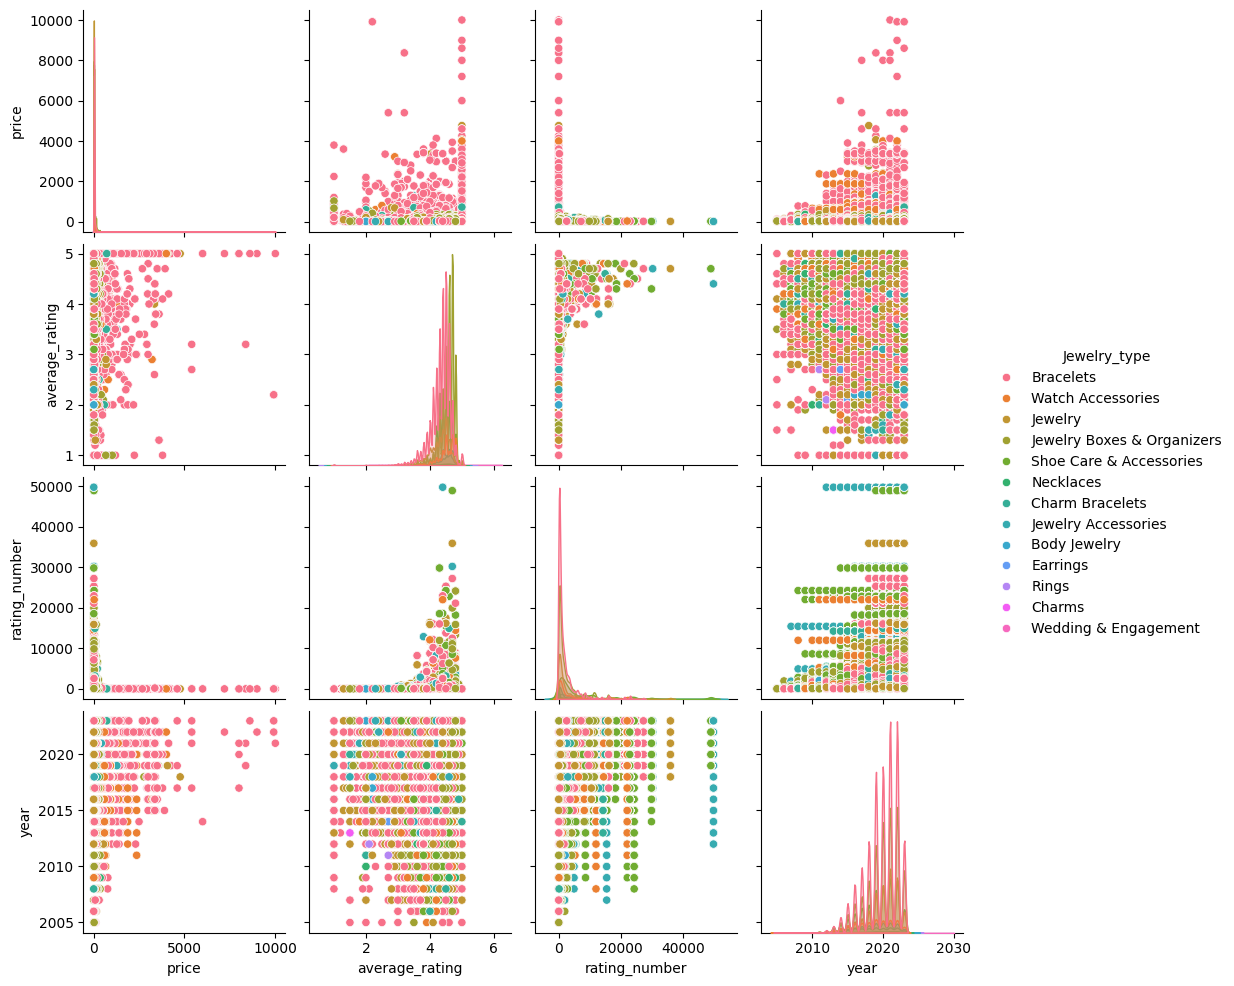

In [37]:
ax = sns.pairplot(df, vars=['price', 'average_rating', 'rating_number', 'year'], hue='Jewelry_type', height=2.5)
plt.show()

In [38]:
df_corr = df[['year','price','average_rating','rating_number']].dropna().corr()
df_corr

,year,price,average_rating,rating_number
year,1.000000,-0.030520,0.070442,0.034544
price,-0.030520,1.000000,0.009329,-0.044880
average_rating,0.070442,0.009329,1.000000,0.155103
rating_number,0.034544,-0.044880,0.155103,1.000000


<Axes: >

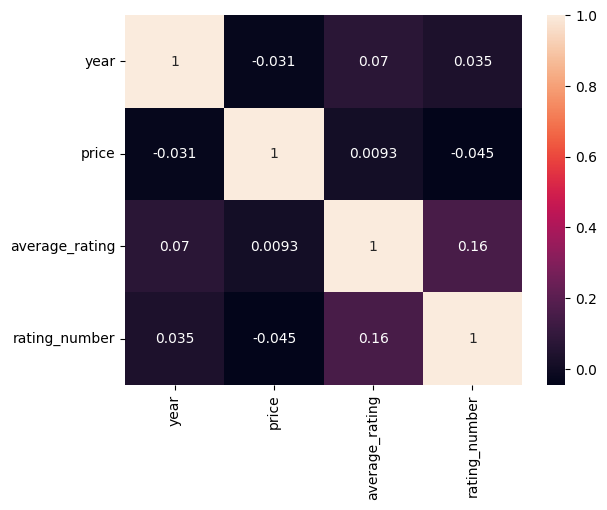

In [39]:
sns.heatmap(df_corr, annot=True)

In [42]:
#Average price per category
df.groupby('Jewelry_type')['price'].mean()

,price
Jewelry_type,
Body Jewelry,21.267124
Bracelets,28.004479
Charm Bracelets,28.526427
Charms,20.220631
Earrings,21.393538
Jewelry,18.765828
Jewelry Accessories,18.607225
Jewelry Boxes & Organizers,38.631928
Necklaces,23.377649


In [43]:
df.groupby('Jewelry_type')['price'].max()

,price
Jewelry_type,
Body Jewelry,1538.50
Bracelets,9999.99
Charm Bracelets,721.00
Charms,400.00
Earrings,345.74
Jewelry,4763.75
Jewelry Accessories,1279.00
Jewelry Boxes & Organizers,3571.99
Necklaces,519.00


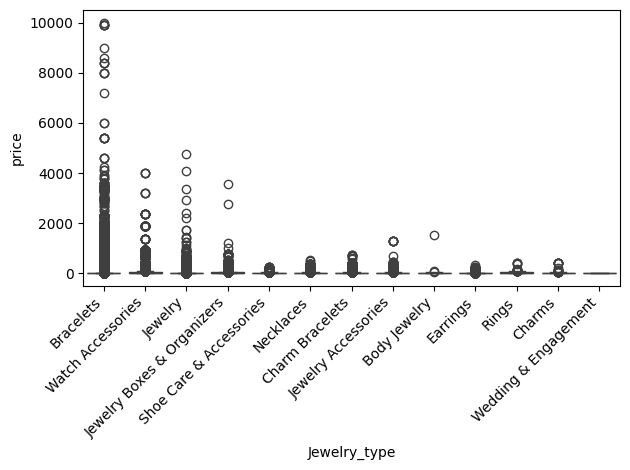

In [48]:
ax=sns.boxplot(x='Jewelry_type', y='price', data=df)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()